# Word Embeddings com SkipGram Vanilla

### Word2Vec

No Word2Vec, gostariamos de maximizar a probabilidade da posição do one-hot-encoding da palavra alvo ser a maior dentre todas as demais posições.<br>

Assim, se dada uma saída houver os seguintes logits (em redes neurais, qualquer valor bruto que é posteriormente convertido em uma probabilidade é chamado de logit): $[0.4, 0.2, 0.3, 0.1]$, e supondo que temos uma frase "eu sou um estudante", onde para cada posição do one-hot-encoding

- a primeira posição seja relacionada a palavra "eu";
- a segunda posição seja relacionada a palavra "sou";
- a terceira posição seja relacionada a palavra "um";
- a quarta posição seja relacionada a palavra "estudante".
<br>
Supondo que a sentença "eu sou um estudante" seja dada ao modelo, assim, gostariamos de maximizar a probabilidade da palavra na posição 4 ser a maior dentre os logits. No mundo perfeito, a predição deveria ser $[0, 0, 0, 1]$, onde teriamos uma probabilidade de 100% para a classe de "estudante", mas no mundo real isso é muito complicado. Sendo assim, gostariamos de encontrar alguma maneira de maximiizar a probabilidade do modelo se aproximar do mundo real.

Pensando em palavras, gostariamos de maximizar a probabilidade de dado um sentença predizer a palavra alvo, ou predizer uma determinada palavra a partir de uma sentença de entrada.<br><br>

Assim, podemos reescrever essa frase da seguinte maneira:<br><br>

$$P(palavra_{alvo} | palavra_{contexto})$$<br>

Como os logits da rede neural do Word2Vec é da seguinte forma:

$$z = W_2^{T}W_1^{T}X$$<br>

E a transformação desses logits em probabilidades é dada pelo Softmax<br><br>

$$Softmax(v)_i = \frac{e^{v_i}}{\sum_{j=1}^{N} e^{v_j}}$$

, onde $i$ refere-se a cada posição do array $v$.

Como gostariamos de aumentar a probabilidade da posição 4 ser a maior. Assim,

Uma forma de recuperar a probabilidade correspondente à classe correta é da seguinte maneira:

$$s(\hat{y}, y) = \prod_{k=1}^{N}{\hat{y}_k}^{y_k}$$

Para demonstrar que isso é verdade, suponha que, após aplicar a função Softmax aos logits, o modelo produza as probabilidades $\hat{y} = [0.4,0.2,0.3,0.1]$ e que o vetor de valores reais seja $y = [0,0,0,1]$.

Assim,

$$s(\hat{y}, y) = 0.4^0 \times 0.2^0 \times 0.3^0 \times 0.1^1 = 0.1$$<br>

Assim, $$\prod_{k=1}^{N}{\hat{y}_k}^{y_k} = 0.1$$


Ou seja, já conseguimos recuperar a probabilidade correspondente à classe correta. Essa probabilidade será utilizada para medir o quão bem o modelo está prevendo a palavra alvo. Com isso, será facil compará-lo com o valor real e descobrir o erro total.

A verossimilhança (likelihood) da classe correta é dada por:

$$\mathcal{L} = \prod_{k=1}^{N}{\hat{y}_k}^{y_k}$$

Aplicando o logaritmo em ambos os lados, conseguimos transformar o produto em soma, como:

$$\log \mathcal{L} = log \prod_{k=1}^{N}{\hat{y}_k}^{y_k} = \sum_{k=1}^{N}log ({\hat{y}_k}^{y_k}) = \sum_{k=1}^{N}{y_k} \cdot log({\hat{y}_k})$$

que nada mais é que o log likelihood.

Todos os algoritmos de treinamento de redes neurais foram formulados para minimizar uma função de perda. Então, em vez de procurar max $log \mathcal{L}$

definimos uma função de custo

$$\mathcal{J} = -log \mathcal{L}$$

$$\mathcal{J} = -log \prod_{k=1}^{N}{\hat{y}_k}^{y_k} = -\sum_{k=1}^{N}log ({\hat{y}_k}^{y_k}) = -\sum_{k=1}^{N}{y_k} \cdot log({\hat{y}_k})$$

$$\mathcal{J} = -\sum_{k=1}^{N}{y_k} \cdot log({\hat{y}_k})$$

$$\mathcal{J}= -\sum_{k=1}^{N}{y_k} \cdot \log\left(\frac{e^{v_k}}{\sum_{j=1}^{N}e^{v_j}}\right)$$

$$\mathcal{J}=-\sum_{k=1}^{N}y_k\left(\log(e^{v_k})-\log\left(\sum_{j=1}^{N}e^{v_j}\right)\right)$$

$$\mathcal{J} = -\sum_{k=1}^{N}{y_k} \cdot (v_k - log \sum_{j=1}^{N} e^{v_j})$$

$$\mathcal{J} = -\sum_{k=1}^{N}{y_k} \cdot v_k + \sum_{k=1}^{N}{y_k} \cdot log \sum_{j=1}^{N} e^{v_j}$$

Como $y$ é o vetor de valores reais, onde no exemplo y é dado por

$$[0,0,0,1]$$

Como $y$ é um vetor one-hot e $v$ representa o vetor de logits produzido pela rede, temos então a soma dos produtos de cada elemento

$$[0,0,0,1] \cdot [0.4, 0.2, 0.3, 0.1] = 0.1$$

$$\sum_{k=1}^{N}{y_k} \cdot v_k = 0 \cdot 0.4 + 0 \cdot 0.2 + 0 \cdot 0.3 + 1 \cdot 0.1 = 0.1$$

Isso significa que o produto escalar entre o vetor one-hot y e o vetor de logits v recupera exatamente o logit correspondente à classe correta. Isso ocorre porque apenas a posição da classe correta possui valor 1, enquanto todas as demais posições são iguais a 0.

Assim,

$$\sum_{k=1}^{N}{y_k} \cdot v_k = v_{target}$$

Logo,

$$v_{target} = y^Tv = y^TW_2^{T} W_1^{T}X$$

$$\mathcal{J} = -v_{target} + \sum_{k=1}^{N}{y_k} \cdot log \sum_{j=1}^{N} e^{v_j}$$

Isso significa que

- $-v_{target}$ quer aumentar o logit da palavra correta
- $\sum_{k=1}^{N}{y_k} \cdot log \sum_{j=1}^{N} e^{v_j}$ atua como um termo de normalização, penalizando o crescimento simultâneo dos logits e garantindo que as probabilidades produzidas pelo Softmax permaneçam normalizadas.

<br>
Sabemos que $v_{target}$ no Word2Vec pode ser dado por $yW_2^{T}W_1^{T}X$, ou seja, com isso, conseguimos recuperar o valor contido na posição alvo.

Assim,

$$\mathcal{J} = -yW_2^{T}W_1^{T}X + \sum_{k=1}^{N}{y_k} \cdot log \sum_{j=1}^{N} e^{v_j}$$

Como a soma dos termos do one-hot-encoding do valor real de y sempre é 1:

$$[0,0,0,1] = 1$$

então,

$$ \sum_{k=1}^{N}{y_k} = 1$$

logo,

$$\mathcal{J} = -yW_2^{T}W_1^{T}X + 1 \cdot log \sum_{j=1}^{N} e^{v_j}$$
$$\mathcal{J} = -yW_2^{T}W_1^{T}X + log \sum_{j=1}^{N} e^{v_j}$$
$$\mathcal{J} = - y^T W_2^{T} W_1^{T} X + \log \sum_{j=1}^{N} e^{(W_2^{T} W_1^{T} X)_j}$$

ou

$$\mathcal{J} = - v_{target} + \log \sum_{j=1}^{N} e^{(W_2^{T} W_1^{T} X)_j}$$

que é a forma da perda de entropia cruzada (negative log-likelihood) para o Word2Vec com Softmax.

sendo

$$v = W_2^{T}W_1^{T}X$$

$$\mathcal{J}=-y^{T}v+\log\left(\sum_{j=1}^{N} e^{v_j}\right)$$

onde, $$target = y^Tv$$

Como os logits são dados por

$$v = W_2^{T}W_1^{T}X$$

primeiramente calculamos a derivada da função de perda em relação aos logits:

$$\frac{\partial \mathcal{J}}{\partial v}=\frac{\partial}{\partial v}\left(-y^{T}v+\log\sum_{j=1}^{N}e^{v_j}\right)$$

Derivando cada termo separadamente, temos

$$\frac{\partial(-y^{T}v)}{\partial v}=-y$$

e

$$\frac{\partial}{\partial v}\log\sum_{j=1}^{N}e^{v_j}=\hat{y}$$

onde

$$\hat{y}=\text{Softmax}(v)$$

Assim,

$$\boxed{\frac{\partial \mathcal{J}}{\partial v}=\hat{y}-y}$$

Agora vamos derivar a perda $J$ em relação a $W_2$:

$$\frac{\partial \mathcal{J}}{\partial W_2} = \frac{\partial \mathcal{J}}{\partial v} \cdot \frac{\partial v}{\partial W_2}$$

ou seja,

$$\frac{\partial \mathcal{J}}{\partial W_2} = (\hat{y}-y) \cdot \frac{\partial v}{\partial W_2}$$

Como

$$h=W_1^{T}X$$

os logits também podem ser escritos como

$$v=W_2^{T}h$$

Aplicando a regra da cadeia, obtemos a derivada em relação à matriz de pesos da camada de saída:

$$\boxed{
\frac{\partial \mathcal{J}}{\partial W_2}=(\hat{y}-y)h}$$

Mas, para compatibilizar as dimensões na multiplicação, fazemos

$$\boxed{
\frac{\partial \mathcal{J}}{\partial W_2}=h(\hat{y}-y)^T}$$

Substituindo $h=W_1^{T}X$, temos

$$\boxed{\frac{\partial \mathcal{J}}{\partial W_2}=W_1^{T}X(\hat{y}-y)^T}$$

Agora calculamos a derivada da perda em relação ao vetor oculto \(h\).

Pela regra da cadeia,

$$
\frac{\partial \mathcal{J}}{\partial h}
=
\frac{\partial \mathcal{J}}{\partial v}
\frac{\partial v}{\partial h}
$$

Como

$$
\frac{\partial \mathcal{J}}{\partial v}=\hat{y}-y
$$

e

$$
v=W_2^{T}h,
$$

temos

$$
\frac{\partial v}{\partial h}=W_2.
$$

Assim,

$$
\boxed{
\frac{\partial \mathcal{J}}{\partial h}
=
W_2(\hat{y}-y)
}
$$

Como

$$
h=W_1^{T}X,
$$

novamente pela regra da cadeia,

$$
\frac{\partial \mathcal{J}}{\partial W_1}
=
\frac{\partial \mathcal{J}}{\partial h}
\frac{\partial h}{\partial W_1}.
$$

Como

$$
\frac{\partial h}{\partial W_1}=X,
$$

obtemos

$$
\boxed{
\frac{\partial \mathcal{J}}{\partial W_1}
=
X\left(W_2(\hat{y}-y)\right)^T
}
$$

Finalmente, as matrizes de pesos são atualizadas utilizando descida do gradiente:

$$
W_1
\leftarrow
W_1-\eta\frac{\partial\mathcal{J}}{\partial W_1},
$$

$$
W_2
\leftarrow
W_2-\eta\frac{\partial\mathcal{J}}{\partial W_2},
$$

Finalmente, as matrizes de pesos são atualizadas utilizando descida do gradiente:

$$
W_1^{(t+1)}
=
W_1^{(t)}
-
\eta
X\left(W_2^{(t)}(\hat{y}-y)\right)^T,
$$

$$
W_2^{(t+1)}
=
W_2^{(t)}
-
\eta
\left(W_1^{(t)T}X\right)(\hat{y}-y)^T.
$$

onde $\eta$ representa a taxa de aprendizado.


## Tratamento de Texto

In [ ]:
!pip install contractions
!pip install pypdf

import numpy as np
from datetime import datetime

import requests
from pypdf import PdfReader

# Para a leitura dos dados
import pandas as pd

# Manipulação de texto
import nltk.corpus
from nltk                             import pos_tag, SnowballStemmer
from nltk.tokenize                    import word_tokenize

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

from nltk.corpus import wordnet

# Prepraração dos dados
from sklearn.feature_extraction.text  import TfidfVectorizer
from sklearn.model_selection          import train_test_split

# Modelos de classificação
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.naive_bayes import MultinomialNB

# Avaliação
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
import contractions

language = "portuguese"
stop_words = nltk.corpus.stopwords.words(language)
stemmer = SnowballStemmer(language)
lemmatizer = nltk.stem.WordNetLemmatizer()

def remove_palavras_pequenas_grandes(tokens):
    return [token.lower()for token in tokens if len(token)>2 and len(token)<16]

def remove_stopwords(tokens):
    nao_stop_words = [token for token in tokens if token.lower() not in   stop_words]
    return nao_stop_words

def stemming(tokens):
    palavras_stemmizadas = [stemmer.stem(token) for token in tokens]
    return palavras_stemmizadas

def corrigir_documento(document):
    return contractions.fix(document)

def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'): # Adjetivo
        return wordnet.ADJ
    elif treebank_tag.startswith('V'): # Verbo
        return wordnet.VERB
    elif treebank_tag.startswith('N'): # Substantivo
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):# Advérbio
        return wordnet.ADV
    else:
        return None

def lemmatize(tokens):
    lemmatized_tokens = []
    pos_tagged = pos_tag(tokens)
    for token, tag in pos_tagged:
        wordnet_pos = get_wordnet_pos(tag) or wordnet.NOUN
        lemmatized_tokens.append(lemmatizer.lemmatize(token, pos=wordnet_pos))
    return lemmatized_tokens

def process_corpus(corpus):
    corpus_processed = []
    for document in corpus:
        document = corrigir_documento(document)
        tokens = word_tokenize(document)
        tokens = remove_stopwords(tokens)
        tokens = remove_palavras_pequenas_grandes(tokens)
        tokens = lemmatize(tokens)
        #tokens = stemming(tokens)
        corpus_processed.append(" ".join(tokens))
    return corpus_processed

url = "https://bd.camara.leg.br/bd/bitstream/handle/bdcamara/15261/constituicao_federal_35ed.pdf"

resp = requests.get(url)
resp.raise_for_status()
with open("guia_bolso.pdf", "wb") as f:
    f.write(resp.content)

reader = PdfReader("guia_bolso.pdf")
all_text = []
for i, page in enumerate(reader.pages):
    text = page.extract_text()
    all_text.append(text or "")

corpus_processed = process_corpus(all_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


## Preparação dos dados e treino

In [ ]:
palavras = " ".join(corpus_processed).split(" ")

vocab = list(set(palavras))
n_vocab = len(vocab)

In [ ]:
token_to_id = {y: x for x, y in enumerate(vocab)}
id_to_token = {y: x for x, y in token_to_id.items()}

dataset = []
window_size = 5

for i in range(len(palavras)):
    source=palavras[i]
    target=palavras[max(i - window_size//2, 0):i] + palavras[i+1:i + 1 + window_size//2]
    dataset.append((source, target))

In [ ]:
import numpy as np

class WordEmbeddings:
    def __init__(self, n_vocab, hidden_dim):
        self.w = np.random.rand(n_vocab, hidden_dim) * 0.1
        self.w_ = np.random.rand(hidden_dim, n_vocab) * 0.1

    def forward(self, x):
        h = self.w.T @ x
        v = self.w_.T @ h
        return v, h

In [ ]:
model = WordEmbeddings(n_vocab=n_vocab, hidden_dim=50)

In [ ]:
is_training = True
epochs = 6
learning_rate = 0.025
weights_decay = 10e-3

In [ ]:
import os
from datetime import datetime

def softmax(x):
    e_x = np.exp(x - np.max(x, axis=0, keepdims=True))
    return e_x / np.sum(e_x, axis=0, keepdims=True)


def train_model():
    losses = []

    for epoch in range(epochs):
        print(f"Epoch {epoch + 1}/{epochs}")

        batch_counter = 0
        epoch_loss_total = 0

        for source_word, target_context_words in dataset:
            index_id = token_to_id[source_word]
            x_one_hot = np.zeros((n_vocab, 1))
            x_one_hot[index_id, 0] = 1

            h = model.w[index_id]
            h = np.repeat(h[:, None], len(target_context_words), axis=1)
            v = model.w_.T @ h
            y_hat = softmax(v)

            y_true_one_hot = np.zeros((n_vocab, len(target_context_words)))
            for i, target_word in enumerate(target_context_words):
                target_id = token_to_id[target_word]
                y_true_one_hot[target_id, i] = 1

            target_score = np.sum(y_true_one_hot * v, axis=0)
            log_sum_exp = np.log(np.sum(np.exp(v - np.max(v, axis=0, keepdims=True)), axis=0)) + np.max(v, axis=0)
            current_loss = np.mean(-target_score + log_sum_exp)

            epoch_loss_total += current_loss

            dJ_dv = y_hat - y_true_one_hot
            dJ_dW2 = h @ dJ_dv.T
            dJ_dh = model.w_ @ dJ_dv
            dJ_dW1 = x_one_hot @ np.sum(dJ_dh, axis=1, keepdims=True).T

            model.w -= learning_rate * (dJ_dW1 + weights_decay * model.w)
            model.w_ -= learning_rate * (dJ_dW2 + weights_decay * model.w_)

            if batch_counter % 1000 == 0:
                print(f"Batch {batch_counter}/{len(dataset)}, Loss: {current_loss:.4f}")

            batch_counter += 1

        avg_epoch_loss = epoch_loss_total / len(dataset)
        losses.append(avg_epoch_loss)
        print(f"Epoch {epoch + 1}/{epochs}, Average Loss: {avg_epoch_loss:.4f}")


    save_dir = '/content/drive/MyDrive/word2vec_weights'
    os.makedirs(save_dir, exist_ok=True)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename_w = os.path.join(save_dir, f"model_w_{timestamp}.npy")
    filename_w_ = os.path.join(save_dir, f"model_w_prime_{timestamp}.npy")
    np.save(filename_w, model.w)
    np.save(filename_w_, model.w_)
    print(f"Model weights saved to {save_dir}")


if is_training:
    train_model()
else:
    weights_filename_to_load_w = '/content/drive/MyDrive/word2vec_weights/model_w_YYYYMMDD_HHMMSS.npy'
    weights_filename_to_load_w_prime = '/content/drive/MyDrive/word2vec_weights/model_w_prime_YYYYMMDD_HHMMSS.npy'

    if os.path.exists(weights_filename_to_load_w) and os.path.exists(weights_filename_to_load_w_prime):
        model.w = np.load(weights_filename_to_load_w)
        model.w_ = np.load(weights_filename_to_load_w_prime)
        print(f"Model weights loaded from {os.path.dirname(weights_filename_to_load_w)}")
    else:
        print("Error: Weight files not found. Please provide correct paths.")

Epoch 1/6
Batch 0/110727, Loss: 9.2103
Batch 1000/110727, Loss: 8.6911
Batch 2000/110727, Loss: 9.1658
Batch 3000/110727, Loss: 9.1984
Batch 4000/110727, Loss: 9.2098
Batch 5000/110727, Loss: 9.2156
Batch 6000/110727, Loss: 9.1585
Batch 7000/110727, Loss: 9.2184
Batch 8000/110727, Loss: 9.2091
Batch 9000/110727, Loss: 9.2172
Batch 10000/110727, Loss: 9.2055
Batch 11000/110727, Loss: 9.2065
Batch 12000/110727, Loss: 9.2101
Batch 13000/110727, Loss: 8.5673
Batch 14000/110727, Loss: 9.1516
Batch 15000/110727, Loss: 9.1679
Batch 16000/110727, Loss: 9.2179
Batch 17000/110727, Loss: 9.2164
Batch 18000/110727, Loss: 8.2585
Batch 19000/110727, Loss: 9.2124
Batch 20000/110727, Loss: 9.2173
Batch 21000/110727, Loss: 9.2174
Batch 22000/110727, Loss: 9.2031
Batch 23000/110727, Loss: 9.2054
Batch 24000/110727, Loss: 9.2086
Batch 25000/110727, Loss: 9.2176
Batch 26000/110727, Loss: 9.1193
Batch 27000/110727, Loss: 9.2179
Batch 28000/110727, Loss: 9.2100
Batch 29000/110727, Loss: 9.2184
Batch 30000/1

In [ ]:
embeddings = model.w

In [ ]:
import torch

score = embeddings @ embeddings.T

palavra_interesse = "constituição"
id_palavra_interesse = token_to_id[palavra_interesse]
score_similares_palavra_interesse = score[id_palavra_interesse]

indices_similares = np.argsort(score_similares_palavra_interesse)[-10:][::-1]

palavras_similares = []
coordenadas = []

for idx in indices_similares:
    coordenadas.append(embeddings[idx])
    palavras_similares.append(id_to_token[idx.item()])

coordenadas = np.stack(coordenadas)
coordenadas = coordenadas @ coordenadas.T @ coordenadas

In [ ]:
from sklearn.decomposition import PCA
import numpy

pca = PCA(n_components=2)
coordenadas_np = numpy.array([t for t in coordenadas])
fit = pca.fit_transform(coordenadas_np)

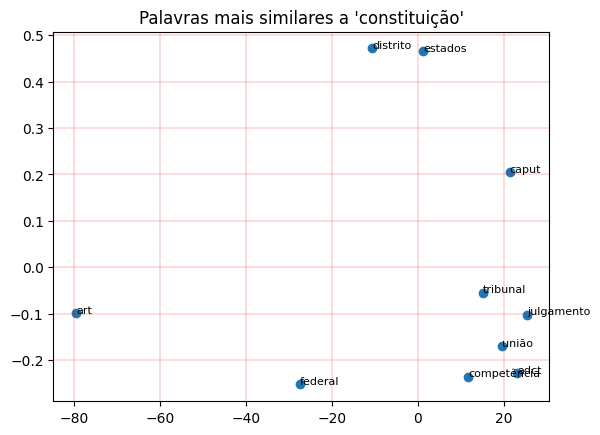

In [ ]:
import matplotlib.pyplot as plt

xs = [x for x, y in fit]
ys = [y for x, y in fit]

plt.scatter(xs, ys)
for i in range(len(palavras_similares)):
    plt.text(xs[i], ys[i], palavras_similares[i], fontsize=8)

plt.title(f"Palavras mais similares a '{palavra_interesse}'")
plt.grid(linestyle="-", linewidth=0.2, color="red")
plt.show()

# Word2Vec com Amostragem Negativa

A função de custo na saída é dada por

$$L = -\sigma(S_{pos}) \cdot \prod_{i = 1}^{K}(1 - \sigma(S_{neg})$$

$$ln(L) = -[ln(\sigma(S_{pos})) + \sum_{i = 1}^{K} ln(1 - \sigma(S_{neg_i}))]$$

$$L = -ln(\sigma(S_{pos})) - \sum_{i = 1}^{K} ln(1 - \sigma(S_{neg_i}))$$

Sendo

$$P1 = -ln(\sigma(S_{pos}))$$
$$P2 = - \sum_{i = 1}^{K} ln(1 - \sigma(S_{neg_i}))$$

E sabendo que a derivada da função sigmoide é igual a:

$$\frac{d \sigma}{d\sigma_{classe}} = \sigma(classe)(1 - \sigma(classe))$$

Assim, para P1 temos:

$$\frac{d P1}{dpos} = -\frac{1}{\sigma(S_{pos})} \cdot (\sigma(S_{pos})(1 - \sigma(S_{pos}))) = -(1 - \sigma(S_{pos})) = \sigma(S_{pos}) - 1$$

Agora para P2, temos:

$$\frac{d P2}{dneg} = \frac{d}{dneg} (-\sum_{i=1}^{K} ln(1 - \sigma(S_{neg_i})))$$

A derivada da soma é a soma das derivadas.

$$\frac{d P2}{dneg} =  -\sum_{i=1}^{K} \frac{d}{dneg} ln(1 - \sigma(S_{neg_i}))= - \sum_{i=1}^{K} \frac{1}{(1 - \sigma(S_{neg_i}))}(-\sigma(S_{neg_i})(1 - \sigma(S_{neg_i}))) $$

$$\frac{d P2}{dneg} = - \sum_{i=1}^{K} \frac{-\sigma(S_{neg_i})(1 - \sigma(S_{neg_i}))}{(1 - \sigma(S_{neg_i}))} = \sum_{i=1}^{K} \sigma(S_{neg_i})$$

Assim,

$$\frac{d P1}{dpos} = \sigma(S_{pos}) - 1$$
$$\frac{d P2}{dneg} = \sum_{i=1}^{K} \sigma(S_{neg_i})$$

Sendo

$S = \mathcal{v_w}^{T} u_c$,
- $v_w$: o embedding da palavra alvo em $W_1$;
- $u_c$: o embedding da palavra de contexto em $W_2$;

$$\frac{dS}{d {v_w}} = u_c$$

$$\frac{dS}{d {u_c}} = v_w$$

$$\frac{dP1}{d v_w} = (\sigma(S_{pos}) - 1)u_{pos}$$

$$\frac{dP1}{d u_{pos}} = (\sigma(S_{pos}) - 1)v_{w}$$

Para cada par negativo:

$$\frac{dP2}{d v_w} = \sum_{i = 1}^{K} \sigma(S_{neg_i})u_{neg_i}$$

$$\frac{dP2}{d u_{neg_i}} = \sigma(S_{neg_i})v_w$$

Portanto, temos:

$$\frac{dL}{dv_w} = (\sigma(S_{pos}) - 1)u_{pos} +  \sum_{i = 1}^{K} \sigma(S_{neg_i})u_{neg_i}$$

Atualização dos pesos:

$$v_w^{(t + 1)} = v_w^{(t)} - \alpha \frac{dL}{dv_w} = v_w^{(t)} - \alpha [(\sigma(S_{pos}) - 1)u_{pos} +  \sum_{i = 1}^{K} \sigma(S_{neg_i})u_{neg_i}]$$

$$u_{pos}^{(t + 1)} = u_{pos}^{(t)} - \alpha \frac{dL}{du_{pos}} = u_{pos}^{(t)} - \alpha [(\sigma(S_{pos}) - 1)v_w]$$

$$u_{neg_i}^{(t + 1)} = u_{neg_i}^{(t)} - \alpha \frac{dL}{du_{neg_i}} = u_{neg_i}^{(t)} - \alpha[(\sigma(S_{neg_i}))v_w]$$

Assim,

$$v_w^{(t + 1)} = v_w^{(t)} - \alpha [(\sigma(S_{pos}) - 1)u_{pos} + \sum_{i = 1}^{K} \sigma(S_{neg_i})u_{neg_i}]$$

$$u_{pos}^{t + 1} = u_{pos}^{(t)} - \alpha [(\sigma(S_{pos}) - 1)v_w]$$

$$u_{neg_i}^{(t + 1)} = u_{neg_i}^{(t)} - \alpha[(\sigma(S_{neg_i}))v_w]$$

## Implementação com Amostragem Negativa

In [ ]:
import os

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

class NegativeSamplingWordEmbeddings:
    def __init__(self, n_vocab, hidden_dim):
        self.w = np.random.rand(n_vocab, hidden_dim) * 0.1
        self.w_ = np.random.rand(n_vocab, hidden_dim) * 0.1

    def get_word_embedding(self, word_id):
        return self.w[word_id]

    def get_context_embedding(self, context_id):
        return self.w_[context_id]


def generate_negative_samples(target_word_id, n_vocab, num_neg_samples=5):
    negative_samples = []
    while len(negative_samples) < num_neg_samples:
        neg_word_id = np.random.randint(0, n_vocab)
        if neg_word_id != target_word_id and neg_word_id not in negative_samples:
            negative_samples.append(neg_word_id)
    return negative_samples

epochs_ns = 6
learning_rate_ns = 0.025
num_negative_samples = 5

def train_negative_sampling_model(model_ns):
    losses_ns = []

    for epoch in range(epochs_ns):
        print(f"Epoch {epoch + 1}/{epochs_ns} (Negative Sampling)")

        epoch_loss_total = 0
        batch_counter = 0

        for source_word, target_context_words in dataset:
            source_word_id = token_to_id[source_word]
            v_w = model_ns.get_word_embedding(source_word_id)

            current_batch_loss = 0

            for positive_context_word in target_context_words:
                pos_word_id = token_to_id[positive_context_word]
                u_pos = model_ns.get_context_embedding(pos_word_id)

                # Calculando S_pos
                S_pos = np.dot(v_w, u_pos)
                current_batch_loss += -np.log(sigmoid(S_pos))

                # Pegando os exemplos negativos
                neg_word_ids = generate_negative_samples(pos_word_id, n_vocab, num_negative_samples)
                u_neg_samples = [model_ns.get_context_embedding(neg_id) for neg_id in neg_word_ids]

                # Calculando S_neg_i e atualizando a perda
                for u_neg_i in u_neg_samples:
                    S_neg_i = np.dot(v_w, u_neg_i)
                    current_batch_loss += -np.log(1 - sigmoid(S_neg_i))

                # Calculando gradientes e atualizando os pesos

                # Gradiente para v_w
                dL_dv_w = (sigmoid(S_pos) - 1) * u_pos
                for i, u_neg_i in enumerate(u_neg_samples):
                    S_neg_i = np.dot(v_w, u_neg_i)
                    dL_dv_w += sigmoid(S_neg_i) * u_neg_i

                # Gradiente para u_pos
                dL_du_pos = (sigmoid(S_pos) - 1) * v_w

                # Gradiente para u_neg_i
                dL_du_neg_list = []
                for u_neg_i in u_neg_samples:
                    S_neg_i = np.dot(v_w, u_neg_i)
                    dL_du_neg_list.append(sigmoid(S_neg_i) * v_w)

                # Atualizando pesos
                model_ns.w[source_word_id] -= learning_rate_ns * dL_dv_w
                model_ns.w_[pos_word_id] -= learning_rate_ns * dL_du_pos
                for i, neg_id in enumerate(neg_word_ids):
                    model_ns.w_[neg_id] -= learning_rate_ns * dL_du_neg_list[i]

            epoch_loss_total += current_batch_loss

            if batch_counter % 1000 == 0:
                print(f"Batch {batch_counter}/{len(dataset)}, Current Avg Loss: {current_batch_loss / len(target_context_words):.4f}")

            batch_counter += 1

        avg_epoch_loss = epoch_loss_total / (len(dataset) * window_size * 2)
        losses_ns.append(avg_epoch_loss)
        print(f"Epoch {epoch + 1}/{epochs_ns} (Negative Sampling), Average Loss: {avg_epoch_loss:.4f}")

    ns_save_dir = '/content/drive/MyDrive/skipgram_negative_sampling_data'
    os.makedirs(ns_save_dir, exist_ok=True)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename_w_ns = os.path.join(ns_save_dir, f"model_ns_w_{timestamp}.npy")
    filename_w_prime_ns = os.path.join(ns_save_dir, f"model_ns_w_prime_{timestamp}.npy")
    np.save(filename_w_ns, model_ns.w)
    np.save(filename_w_prime_ns, model_ns.w_)
    print(f"Negative sampling model weights saved to {ns_save_dir}")

model_ns = NegativeSamplingWordEmbeddings(n_vocab=n_vocab, hidden_dim=50)
print("Starting Negative Sampling Word2Vec training...")
train_negative_sampling_model(model_ns)

Starting Negative Sampling Word2Vec training...
Epoch 1/6 (Negative Sampling)
Batch 0/110727, Current Avg Loss: 4.4284
Batch 1000/110727, Current Avg Loss: 3.1868
Batch 2000/110727, Current Avg Loss: 3.7507
Batch 3000/110727, Current Avg Loss: 3.1069
Batch 4000/110727, Current Avg Loss: 4.1488
Batch 5000/110727, Current Avg Loss: 4.3452
Batch 6000/110727, Current Avg Loss: 3.7480
Batch 7000/110727, Current Avg Loss: 3.5217
Batch 8000/110727, Current Avg Loss: 4.4381
Batch 9000/110727, Current Avg Loss: 4.4306
Batch 10000/110727, Current Avg Loss: 3.1347
Batch 11000/110727, Current Avg Loss: 4.0273
Batch 12000/110727, Current Avg Loss: 4.5579
Batch 13000/110727, Current Avg Loss: 1.3856
Batch 14000/110727, Current Avg Loss: 3.0596
Batch 15000/110727, Current Avg Loss: 3.6377
Batch 16000/110727, Current Avg Loss: 3.0736
Batch 17000/110727, Current Avg Loss: 2.5419
Batch 18000/110727, Current Avg Loss: 2.9677
Batch 19000/110727, Current Avg Loss: 4.2895
Batch 20000/110727, Current Avg Los

In [ ]:
embeddings_ns = model_ns.w

In [ ]:
palavra_interesse_ns = "república"

if palavra_interesse_ns not in token_to_id:
    print(f"A palavra '{palavra_interesse_ns}' não está no vocabulário. Escolha outra palavra.")
else:
    id_palavra_interesse_ns = token_to_id[palavra_interesse_ns]
    embedding_palavra_interesse_ns = embeddings_ns[id_palavra_interesse_ns]
    scores_ns = np.dot(embeddings_ns, embedding_palavra_interesse_ns)
    indices_similares_ns = np.argsort(scores_ns)[-11:][::-1]

    palavras_similares_ns = []
    coordenadas_ns = []

    for idx in indices_similares_ns:
        if id_to_token[idx] != palavra_interesse_ns:
            coordenadas_ns.append(embeddings_ns[idx])
            palavras_similares_ns.append(id_to_token[idx])

    coordenadas_ns = np.array(coordenadas_ns[:10])
    palavras_similares_ns = palavras_similares_ns[:10]

    if len(palavras_similares_ns) == 0:
        print(f"Não foi possível encontrar palavras similares para '{palavra_interesse_ns}'.")
    else:
        coordenadas_ns = np.vstack([embedding_palavra_interesse_ns, coordenadas_ns])
        palavras_similares_ns.insert(0, palavra_interesse_ns)

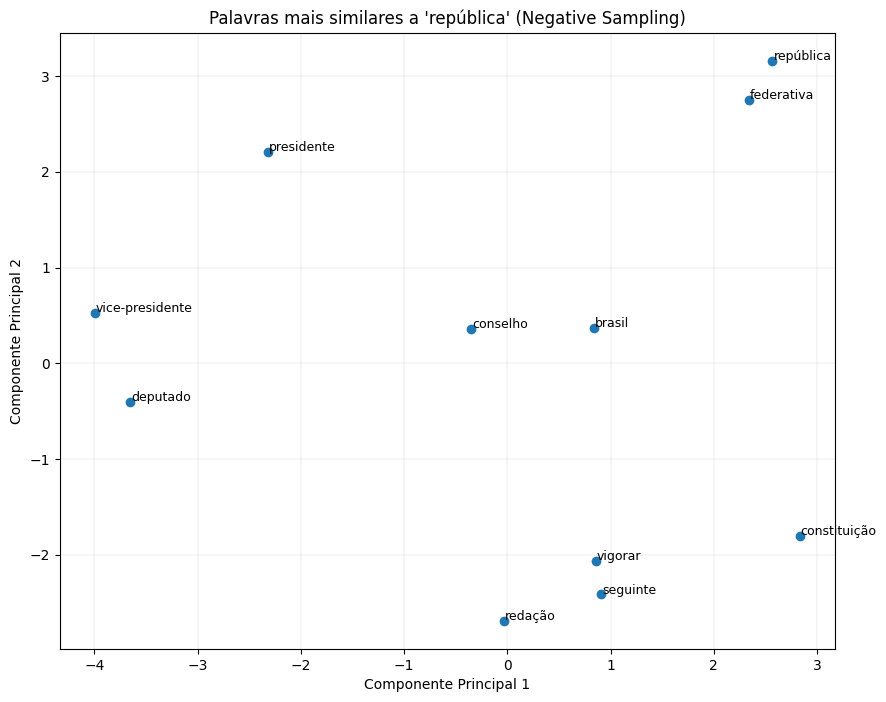

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

if 'coordenadas_ns' in locals() and len(coordenadas_ns) > 0:
    pca_ns = PCA(n_components=2)
    fit_ns = pca_ns.fit_transform(coordenadas_ns)

    xs_ns = [x for x, y in fit_ns]
    ys_ns = [y for x, y in fit_ns]

    plt.figure(figsize=(10, 8))
    plt.scatter(xs_ns, ys_ns)

    for i in range(len(palavras_similares_ns)):
        plt.text(xs_ns[i] + 0.01, ys_ns[i] + 0.01, palavras_similares_ns[i], fontsize=9)

    plt.title(f"Palavras mais similares a '{palavra_interesse_ns}' (Negative Sampling)")
    plt.xlabel("Componente Principal 1")
    plt.ylabel("Componente Principal 2")
    plt.grid(linestyle="-", linewidth=0.2, color="gray", alpha=0.5)
    plt.show()
else:
    print("Não há dados suficientes para plotar. Verifique se a palavra de interesse e suas similares foram encontradas.")
